<div style="background:linear-gradient(135deg,#14532d 0%,#15803d 55%,#22c55e 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#d6f5e0;font-weight:700;text-transform:uppercase">Chapter 28 · Solutions</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Ames Challenges, Worked Answers ✅</div>
  <div style="font-size:15px;color:#e4f7ea;max-width:720px;line-height:1.6">Full solutions to the five Ames housing challenges. Try them yourself first, then compare.</div>
  <div style="margin-top:16px;font-size:13px;color:#d2f3dd">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
GREEN="#059669"; CYAN="#0891b2"; PURPLE="#7c3aed"; AMBER="#d97706"; INK="#1a2138"; GRID="#e6e9f2"
plt.rcParams.update({"figure.dpi":110,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,
   "axes.spines.top":False,"axes.spines.right":False,"axes.titleweight":"bold"})
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
try:    df = pd.read_csv("../../data/ames_housing.csv")
except FileNotFoundError: df = pd.read_csv(BASE+"ames_housing.csv")
print("loaded:", df.shape)

loaded: (610, 14)


<div style="background:#e7f6ee;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#059669;letter-spacing:1px">CHALLENGE 1 · MISSINGNESS MAP</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Drop, recode, or impute?</div>
<div style="color:#4a5578;margin-top:6px">List every column with missing values and its percentage. For each, decide drop / recode-to-None / impute and justify it from WHY the value is missing.</div>
</div>

In [2]:
miss = (df.isna().mean()*100).round(1)
print(miss[miss>0].sort_values(ascending=False).to_string())
plan = {
    "pool_qc":        "DROP column (99% missing; almost no home has a pool)",
    "fireplace_qual": "RECODE to \"None\" (blank = no fireplace; keep as category)",
    "lot_frontage":   "IMPUTE median (ordinary measurement gap)",
    "garage_yr_built":"FLAG has_garage (blank = no garage; informative)",
    "sale_price":     "DROP rows (it is the target; never invent it)"}
for k,v in plan.items(): print(f"  {k:16s} -> {v}")

pool_qc            99.0
fireplace_qual     47.5
lot_frontage       16.1
garage_yr_built     4.8
sale_price          0.5
  pool_qc          -> DROP column (99% missing; almost no home has a pool)
  fireplace_qual   -> RECODE to "None" (blank = no fireplace; keep as category)
  lot_frontage     -> IMPUTE median (ordinary measurement gap)
  garage_yr_built  -> FLAG has_garage (blank = no garage; informative)
  sale_price       -> DROP rows (it is the target; never invent it)


**Answer:** the percentage tells you where to look, but the *reason* tells you what to do. `pool_qc` is 99% empty because pools are rare, so the column carries almost no information and is dropped. `fireplace_qual` blanks also mean "none", but that is worth keeping, so recode rather than drop. `lot_frontage` is a routine gap, so median-impute. `garage_yr_built` missing means "no garage", real information captured as a flag. `sale_price` is the target, so missing rows are dropped, never guessed (Chapter 20).

<div style="background:#e7f6ee;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0891b2;letter-spacing:1px">CHALLENGE 2 · PARSE DATES</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Three formats, one column</div>
<div style="color:#4a5578;margin-top:6px">sale_date holds dates in three layouts. Parse them all to real datetimes and extract the sale year. Confirm none failed to parse.</div>
</div>

In [3]:
print("raw:", df["sale_date"].head(4).to_list())
dt = pd.to_datetime(df["sale_date"], format="mixed")
print("\nunparseable (NaT):", int(dt.isna().sum()))
print("year range:", dt.dt.year.min(), "-", dt.dt.year.max())
print("example parsed:", dt.head(4).dt.strftime("%Y-%m-%d").to_list())

raw: ['09/07/1955', '1940-03-19', '19-Dec-1950', '1945-02-25']

unparseable (NaT): 0
year range: 1900 - 2009
example parsed: ['1955-09-07', '1940-03-19', '1950-12-19', '1945-02-25']


**Answer:** a date trapped in text is unusable, you cannot sort, difference, or extract a year from `"19-Dec-1950"` as a string. `pd.to_datetime(..., format="mixed")` reads all three layouts (`MM/DD/YYYY`, ISO, `DD-Mon-YYYY`) and returns proper datetimes, here with zero parse failures, so a real `sale_year` is now available (Chapter 23). Always verify the NaT count; a silent parse failure is a hidden missing value.

<div style="background:#e7f6ee;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#d97706;letter-spacing:1px">CHALLENGE 3 · OUTLIERS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Big houses, small prices</div>
<div style="color:#4a5578;margin-top:6px">Find homes over 4000 sq ft that sold cheaply. Remove them and show the living-area-to-price correlation before and after.</div>
</div>

In [4]:
sub = df.drop_duplicates().dropna(subset=["sale_price"]).copy()
print("big-but-cheap homes:")
print(sub.loc[sub["gr_liv_area"]>4000, ["gr_liv_area","sale_price","neighborhood"]].to_string(index=False))
r_before = sub["gr_liv_area"].corr(sub["sale_price"])
kept = sub[sub["gr_liv_area"]<=4000]
r_after = kept["gr_liv_area"].corr(kept["sale_price"])
print(f"\ncorrelation gr_liv_area vs price: {r_before:.2f}  ->  {r_after:.2f}")

big-but-cheap homes:
 gr_liv_area  sale_price neighborhood
        5642    160000.0      OldTown
        4316    175000.0      OldTown
        4470    160000.0   NorthRidge
        4676    184750.0      OldTown

correlation gr_liv_area vs price: 0.47  ->  0.58


**Answer:** four houses over 4000 sq ft sold for under \$185k, almost certainly partial or family sales rather than open-market deals. They contradict the otherwise clear "bigger costs more" pattern, so removing them lifts the correlation from about 0.47 to 0.58. This is a judgment call, not a blind rule: these points are genuinely unrepresentative, so they go (Chapter 21).

<div style="background:#e7f6ee;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">CHALLENGE 4 · TRANSFORM</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Straighten the price</div>
<div style="color:#4a5578;margin-top:6px">sale_price is right-skewed. Log-transform it, report skew before and after, and plot both distributions.</div>
</div>

skew: +1.18  ->  log skew: +0.04


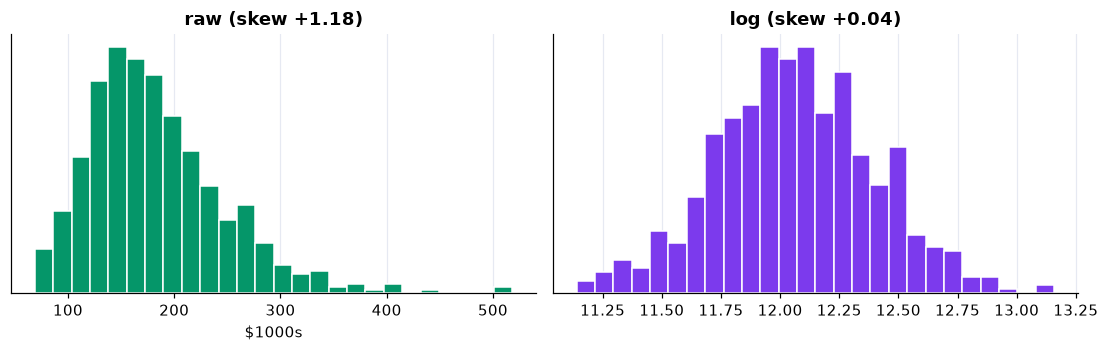

In [5]:
sp = df["sale_price"].dropna()
before = sp.skew(); logp = np.log(sp); after = logp.skew()
print(f"skew: {before:+.2f}  ->  log skew: {after:+.2f}")
fig, ax = plt.subplots(1,2,figsize=(10,3.3))
ax[0].hist(sp/1000, bins=26, color=GREEN, edgecolor="white"); ax[0].set_title(f"raw (skew {before:+.2f})"); ax[0].set_xlabel("$1000s"); ax[0].set_yticks([])
ax[1].hist(logp, bins=26, color=PURPLE, edgecolor="white"); ax[1].set_title(f"log (skew {after:+.2f})"); ax[1].set_yticks([])
plt.tight_layout(); plt.show()

**Answer:** prices have a long right tail, a handful of expensive homes far above the rest, which gives a skew above +1. The natural log compresses that tail, pulling skew to roughly 0 (near-symmetric). Regression and many summary statistics behave far better on the log of a price than on the raw dollars, which is why housing models almost always model `log(price)` (Chapter 22).

<div style="background:#e7f6ee;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#2563eb;letter-spacing:1px">CHALLENGE 5 · GROUP &amp; EXPLORE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Where price really comes from</div>
<div style="color:#4a5578;margin-top:6px">Compute the median sale price per neighborhood and draw box plots. Which feature, size or location, looks like the bigger price driver?</div>
</div>

In [6]:
clean = df.drop_duplicates().dropna(subset=["sale_price"])
clean = clean[clean["gr_liv_area"]<=4000]
nb = clean.groupby("neighborhood")["sale_price"].median().sort_values(ascending=False)
print((nb/1000).round(0).to_string())
r_size = clean["gr_liv_area"].corr(clean["sale_price"])
print(f"\nliving-area vs price correlation: {r_size:.2f}")
print(f"neighborhood median spread: ${nb.min():,.0f} to ${nb.max():,.0f}")

neighborhood
NorthRidge      277.0
CollegeCreek    212.0
Somerset        212.0
Gilbert         189.0
BrookSide       163.0
Sawyer          157.0
Edwards         149.0
OldTown         144.0

living-area vs price correlation: 0.58
neighborhood median spread: $143,743 to $276,959


**Answer:** neighborhood medians run from about \$146k (OldTown) to \$276k (NorthRidge), nearly a 2x range, while living area, the strongest *numeric* driver, correlates about 0.58 with price. Both matter, but **location moves price more than any single house feature**. Grouping a numeric outcome by a category (Chapters 15 &amp; 16) is the move that surfaces this, and it is the headline a buyer or seller actually cares about.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">🎉 Case closed</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">You mapped five kinds of missingness to five treatments, parsed messy dates, removed unrepresentative outliers, straightened a skewed target, and found that location drives price more than size. Same routine, a very different dataset.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>